# Sensitivity Analysis Visualization

Visualizes STA sensitivity to parameter choices:
- Time budget: 60, 75, 90, 120 minutes
- Departure hour: 16:00, 17:00, 18:00 (PT only)

**Outputs:** `figures/sensitivity_*.png`

In [1]:
%cd D:\netmob25

D:\netmob25


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats

In [3]:
# Matplotlib setup (aligned with 8-sp-accessibility-desc-minimal)
mpl.rc('font', size=9)
mpl.rcParams['legend.fontsize'] = 'small'
mpl.rcParams['xtick.labelsize'] = 'small'
mpl.rcParams['ytick.labelsize'] = 'small'
mpl.rcParams['lines.linewidth'] = 1
mpl.rcParams['axes.linewidth'] = 1
mpl.rcParams['xtick.top'] = False
mpl.rcParams['ytick.right'] = False
mpl.rcParams['mathtext.default'] = 'regular'

# Color palette
COLORS = {
    'Car': '#0fbcf9',
    'Public transit': '#05c46b',
    'car': '#0fbcf9',
    'pt': '#05c46b'
}

## 1. Load Data

In [4]:
# Load sensitivity results
df_full = pd.read_csv('results/sensitivity/sta_sensitivity_full.csv')
df_summary = pd.read_csv('results/sensitivity/sta_sensitivity_summary.csv')

print(f"Individual-level records: {len(df_full)}")
print(f"\nParameter combinations:")
print(df_summary[['mode', 'hour', 'budget', 'mean', 'pct_nonzero']])

Individual-level records: 12914

Parameter combinations:
  mode  hour  budget      mean  pct_nonzero
0  car    17      60    561.28        28.67
1  car    17      75   1731.28        39.61
2  car    17      90   4068.59        46.50
3  car    17     120  11547.41        59.74
4   pt    16      90    979.37        31.89
5   pt    17      60     78.05        13.09
6   pt    17      75    340.31        22.16
7   pt    17      90   1024.76        32.15
8   pt    17     120   4156.65        49.38
9   pt    18      90   1028.61        32.15


In [5]:
# Add IHS transformation
df_full['ak_ihs'] = np.arcsinh(df_full['ak'])

# Create readable labels
df_full['mode_label'] = df_full['mode'].map({'car': 'Car', 'pt': 'Public transit'})
df_full['budget_label'] = df_full['budget'].astype(str) + ' min'

df_summary['mode_label'] = df_summary['mode'].map({'car': 'Car', 'pt': 'Public transit'})

## 2. STA Distribution by Time Budget

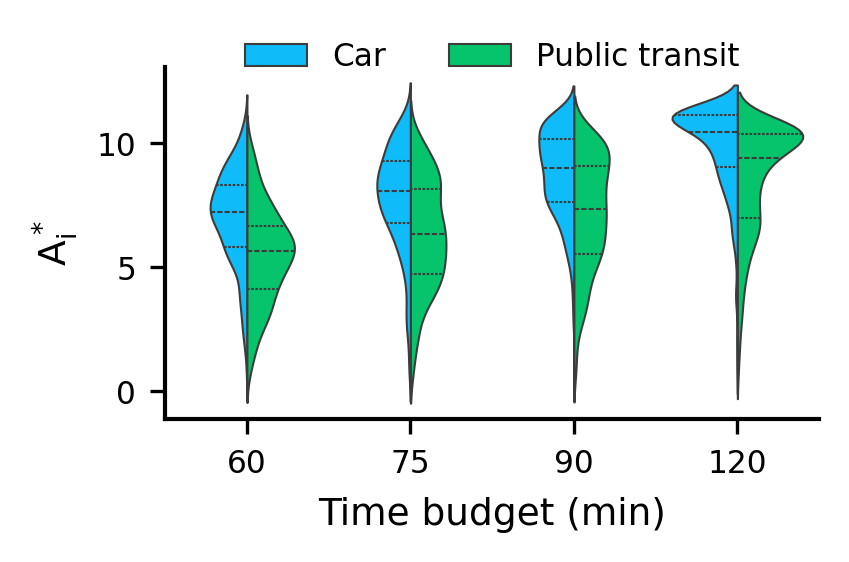

In [30]:
# Filter to hour=17 for budget comparison
df_h17 = df_full[df_full['hour'] == 17].copy()

# Only plot non-zero values for clearer distribution
df_h17_nonzero = df_h17[df_h17['ak'] > 0].copy()

fig, ax = plt.subplots(figsize=(3, 2), dpi=300)

# Split violin plot with both modes
sns.violinplot(
    data=df_h17_nonzero,
    x='budget',
    y='ak_ihs',
    hue='mode_label',
    split=True,
    inner='quart',
    palette={'Car': COLORS['car'], 'Public transit': COLORS['pt']},
    order=[60, 75, 90, 120],
    hue_order=['Car', 'Public transit'],
    linewidth=0.5,
    saturation=1,  # Preserve original color brightness
    ax=ax
)

ax.set_xlabel('Time budget (min)')
ax.set_ylabel('$A_i^*$')
ax.legend(
    title='',
    frameon=False,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),  # move above plot
    ncol=2                    # number of legend items → one row
)
sns.despine(ax=ax)
plt.tight_layout()
fig.savefig('figures/sensitivity_budget_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Share with Non-zero STA by Parameter

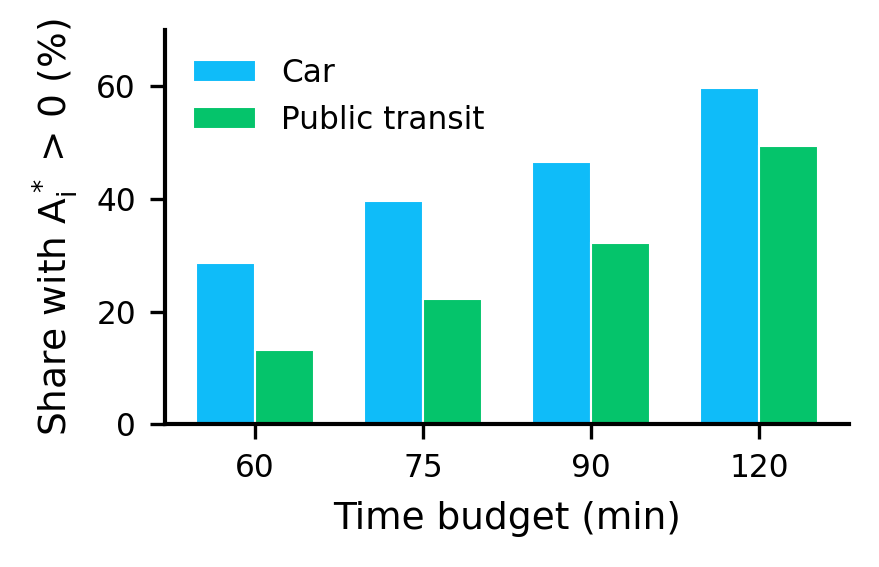

In [31]:
# Filter to hour=17 for budget comparison
df_budget_sens = df_summary[df_summary['hour'] == 17].copy()

fig, ax = plt.subplots(figsize=(3, 2), dpi=300)

x = np.arange(4)  # 4 budget levels
width = 0.35

car_vals = df_budget_sens[df_budget_sens['mode'] == 'car'].sort_values('budget')['pct_nonzero'].values
pt_vals = df_budget_sens[df_budget_sens['mode'] == 'pt'].sort_values('budget')['pct_nonzero'].values

ax.bar(x - width/2, car_vals, width, label='Car', color=COLORS['car'], edgecolor='white', linewidth=0.5)
ax.bar(x + width/2, pt_vals, width, label='Public transit', color=COLORS['pt'], edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(['60', '75', '90', '120'])
ax.set_xlabel('Time budget (min)')
ax.set_ylabel('Share with $A_i^*$ > 0 (%)')
ax.legend(frameon=False, loc='upper left')
ax.set_ylim(0, 70)

sns.despine(ax=ax)
plt.tight_layout()
fig.savefig('figures/sensitivity_budget_nonzero.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Departure Hour Sensitivity (PT only)

In [21]:
# Filter PT, budget=90, compare hours
df_pt_hour = df_full[(df_full['mode'] == 'pt') & (df_full['budget'] == 90)].copy()

print("PT hour sensitivity (budget=90 min):")
print(df_pt_hour.groupby('hour')['ak'].agg(['mean', 'median', lambda x: (x > 0).mean() * 100]))

PT hour sensitivity (budget=90 min):
             mean  median  <lambda_0>
hour                                 
16     979.373299     0.0   31.885936
17    1024.758911     0.0   32.145172
18    1028.607907     0.0   32.145172


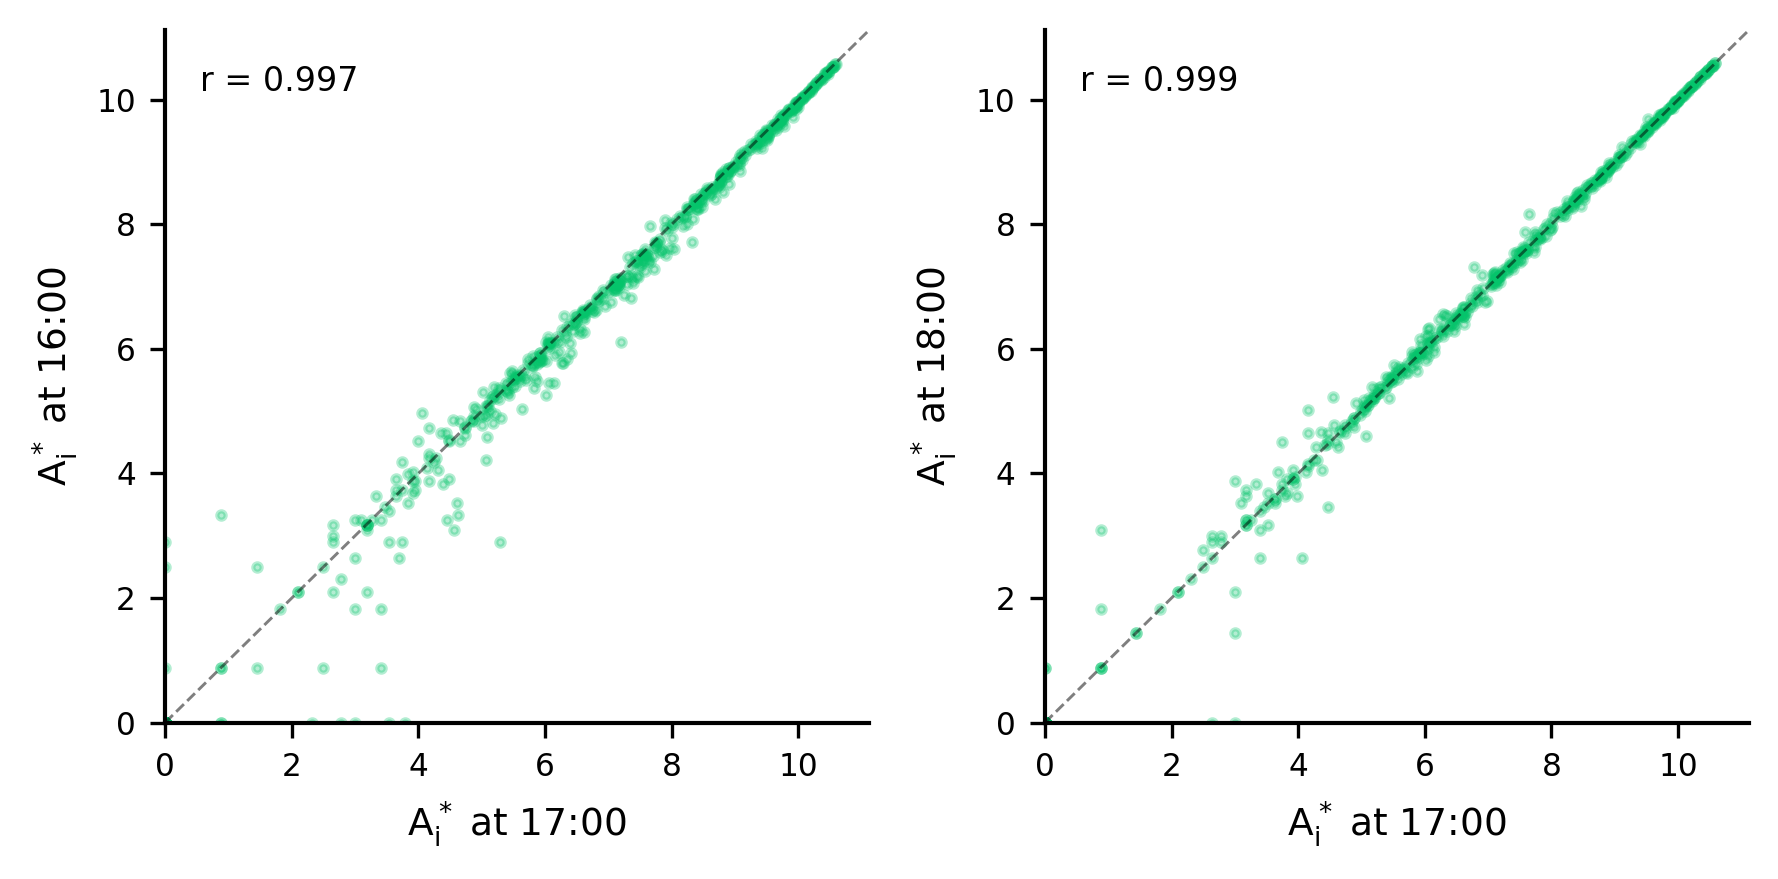

In [34]:
# Pivot for pairwise comparison
df_pt_wide = df_pt_hour.pivot_table(
    index='ID',
    columns='hour',
    values='ak_ihs',
    aggfunc='first'
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(6, 3), dpi=300)

# 16:00 vs 17:00
ax = axes[0]
ax.scatter(df_pt_wide[17], df_pt_wide[16], alpha=0.3, s=4, color=COLORS['pt'])
lims = [0, df_pt_wide[[17, 16]].max().max() * 1.05]
ax.plot(lims, lims, 'k--', lw=0.7, alpha=0.5)
ax.set_xlabel('$A_i^*$ at 17:00')
ax.set_ylabel('$A_i^*$ at 16:00')
ax.set_xlim(lims)
ax.set_ylim(lims)
r = df_pt_wide[[16, 17]].corr().iloc[0, 1]
ax.text(0.05, 0.95, f'r = {r:.3f}', transform=ax.transAxes, va='top', fontsize=8)
sns.despine(ax=ax)

# 17:00 vs 18:00
ax = axes[1]
ax.scatter(df_pt_wide[17], df_pt_wide[18], alpha=0.3, s=4, color=COLORS['pt'])
lims = [0, df_pt_wide[[17, 18]].max().max() * 1.05]
ax.plot(lims, lims, 'k--', lw=0.7, alpha=0.5)
ax.set_xlabel('$A_i^*$ at 17:00')
ax.set_ylabel('$A_i^*$ at 18:00')
ax.set_xlim(lims)
ax.set_ylim(lims)
r = df_pt_wide[[17, 18]].corr().iloc[0, 1]
ax.text(0.05, 0.95, f'r = {r:.3f}', transform=ax.transAxes, va='top', fontsize=8)
sns.despine(ax=ax)

plt.tight_layout()
fig.savefig('figures/sensitivity_hour_pt.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Summary Statistics Table

In [11]:
# Create summary table for paper
df_table = df_summary.copy()
df_table['Setting'] = df_table.apply(
    lambda r: f"{r['mode_label']}, {r['hour']}:00, {r['budget']} min", axis=1
)
df_table = df_table[['Setting', 'mean', 'median', 'std', 'pct_nonzero']]
df_table.columns = ['Setting', 'Mean', 'Median', 'Std', '% Non-zero']
df_table = df_table.round(1)

print("=== STA Sensitivity Summary ===")
print(df_table.to_string(index=False))

# Save as CSV
df_table.to_csv('results/sensitivity/sta_sensitivity_table.csv', index=False)
print("\nSaved: results/sensitivity/sta_sensitivity_table.csv")

=== STA Sensitivity Summary ===
                       Setting    Mean  Median     Std  % Non-zero
            Car, 17:00, 60 min   561.3     0.0  2015.3        28.7
            Car, 17:00, 75 min  1731.3     0.0  4626.7        39.6
            Car, 17:00, 90 min  4068.6     0.0  8203.9        46.5
           Car, 17:00, 120 min 11547.4  2077.0 14744.0        59.7
 Public transit, 16:00, 90 min   979.4     0.0  2948.6        31.9
 Public transit, 17:00, 60 min    78.0     0.0   542.3        13.1
 Public transit, 17:00, 75 min   340.3     0.0  1468.9        22.2
 Public transit, 17:00, 90 min  1024.8     0.0  3042.6        32.2
Public transit, 17:00, 120 min  4156.6     0.0  7080.0        49.4
 Public transit, 18:00, 90 min  1028.6     0.0  3049.8        32.2

Saved: results/sensitivity/sta_sensitivity_table.csv


## 7. Key Findings

In [36]:
print("=" * 60)
print("SENSITIVITY ANALYSIS KEY FINDINGS")
print("=" * 60)

# Budget sensitivity
df_b = df_summary[df_summary['hour'] == 17]
print("\n1. TIME BUDGET SENSITIVITY (hour=17:00)")
print("-" * 40)
for mode in ['car', 'pt']:
    df_m = df_b[df_b['mode'] == mode].sort_values('budget')
    pct_60 = df_m[df_m['budget'] == 60]['pct_nonzero'].values[0]
    pct_120 = df_m[df_m['budget'] == 120]['pct_nonzero'].values[0]
    mode_label = 'Car' if mode == 'car' else 'PT'
    print(f"  {mode_label}: {pct_60:.1f}% → {pct_120:.1f}% with STA > 0 (60 → 120 min)")

# Hour sensitivity (PT)
df_h = df_summary[(df_summary['mode'] == 'pt') & (df_summary['budget'] == 90)]
print("\n2. DEPARTURE HOUR SENSITIVITY (PT, budget=90 min)")
print("-" * 40)
for _, row in df_h.iterrows():
    print(f"  {int(row['hour'])}:00: mean={row['mean']:.0f}, {row['pct_nonzero']:.1f}% non-zero")


print("\n" + "=" * 60)

SENSITIVITY ANALYSIS KEY FINDINGS

1. TIME BUDGET SENSITIVITY (hour=17:00)
----------------------------------------
  Car: 28.7% → 59.7% with STA > 0 (60 → 120 min)
  PT: 13.1% → 49.4% with STA > 0 (60 → 120 min)

2. DEPARTURE HOUR SENSITIVITY (PT, budget=90 min)
----------------------------------------
  16:00: mean=979, 31.9% non-zero
  17:00: mean=1025, 32.1% non-zero
  18:00: mean=1029, 32.1% non-zero

